In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

ModuleNotFoundError: No module named 'numpy'

In [ ]:
from IPython.display import Image, display
display(Image(filename="/kaggle/input/imagett/3bB2UnWTUkslTngQMkwRZbO3qdYkhD.jpg"))


In [ ]:
import csv
import matplotlib.pyplot as plt

file_path = "/kaggle/input/eda-matplolib-titanic/tested.csv"

with open(file_path, "r", encoding="utf-8") as f:
    reader = csv.reader(f)
    header = next(reader)
    rows = [row for row in reader]

print("Columns:", header)
print("First 5 rows:")
for r in rows[:5]:
    print(r)


Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
First 5 rows:
['892', '0', '3', 'Kelly, Mr. James', 'male', '34.5', '0', '0', '330911', '7.8292', '', 'Q']
['893', '1', '3', 'Wilkes, Mrs. James (Ellen Needs)', 'female', '47', '1', '0', '363272', '7', '', 'S']
['894', '0', '2', 'Myles, Mr. Thomas Francis', 'male', '62', '0', '0', '240276', '9.6875', '', 'Q']
['895', '0', '3', 'Wirz, Mr. Albert', 'male', '27', '0', '0', '315154', '8.6625', '', 'S']
['896', '1', '3', 'Hirvonen, Mrs. Alexander (Helga E Lindqvist)', 'female', '22', '1', '1', '3101298', '12.2875', '', 'S']


In [ ]:
def try_float(s):
    try:
        return float(s)
    except:
        return None

age_index = header.index("Age")
ages = [try_float(r[age_index]) for r in rows if r[age_index] != ""]
print(f"Non-missing ages: {len(ages)}")


Non-missing ages: 332


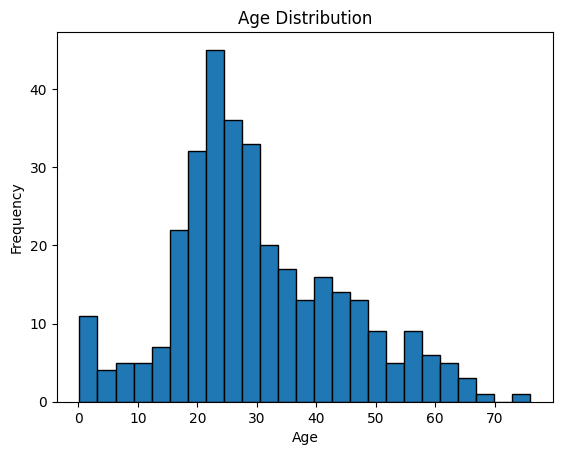

In [ ]:
plt.hist(ages, bins=25, edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


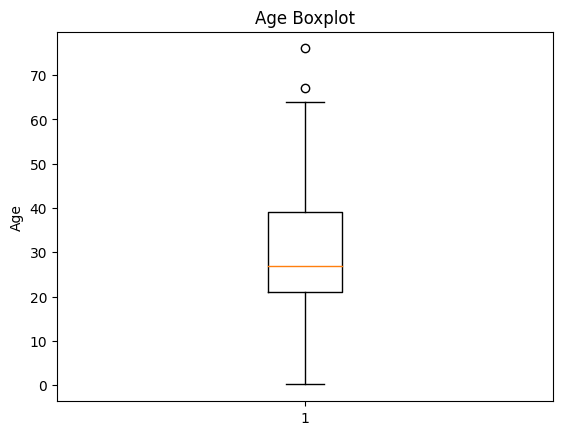

In [ ]:
plt.boxplot(ages, vert=True)
plt.title("Age Boxplot")
plt.ylabel("Age")
plt.show()


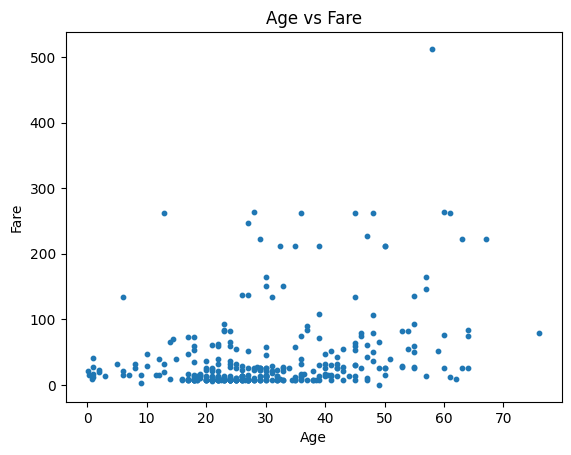

In [ ]:
fare_index = header.index("Fare")
fares = []
age_vals = []

for r in rows:
    age = try_float(r[age_index])
    fare = try_float(r[fare_index])
    if age is not None and fare is not None:
        age_vals.append(age)
        fares.append(fare)

plt.scatter(age_vals, fares, s=10)
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()


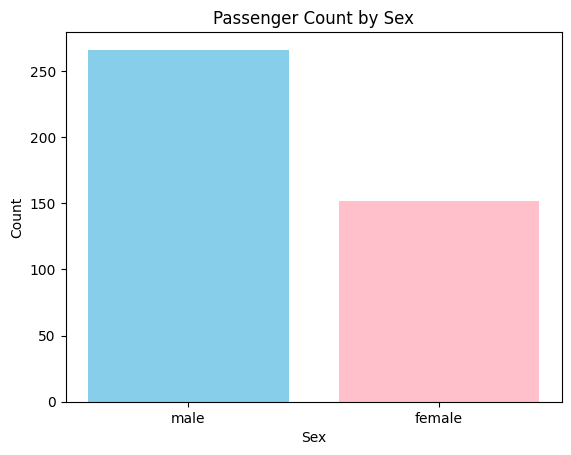

In [ ]:
sex_index = header.index("Sex")
from collections import Counter

sex_counts = Counter(r[sex_index] for r in rows)
plt.bar(sex_counts.keys(), sex_counts.values(), color=["skyblue", "pink"])
plt.title("Passenger Count by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()


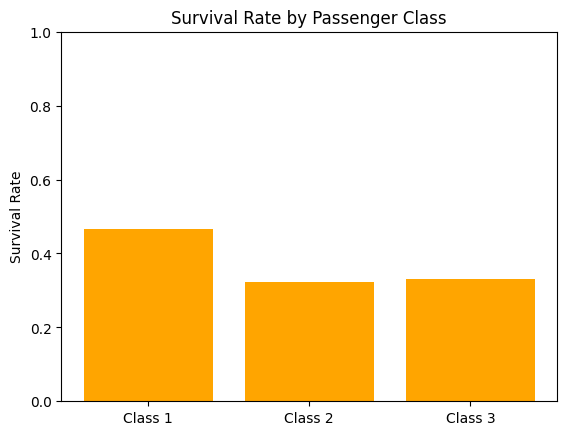

In [ ]:
pclass_index = header.index("Pclass")
survived_index = header.index("Survived")

class_survival = {1: [0,0], 2: [0,0], 3: [0,0]}  # {class: [survivors, total]}
for r in rows:
    pclass = int(r[pclass_index])
    survived = int(r[survived_index])
    class_survival[pclass][1] += 1
    class_survival[pclass][0] += survived

classes = sorted(class_survival.keys())
rates = [class_survival[c][0] / class_survival[c][1] for c in classes]

plt.bar(classes, rates, tick_label=["Class 1", "Class 2", "Class 3"], color="orange")
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0,1)
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = "/kaggle/input/eda-matplolib-titanic/tested.csv"
df = pd.read_csv(file_path)

print(df.head())


   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  


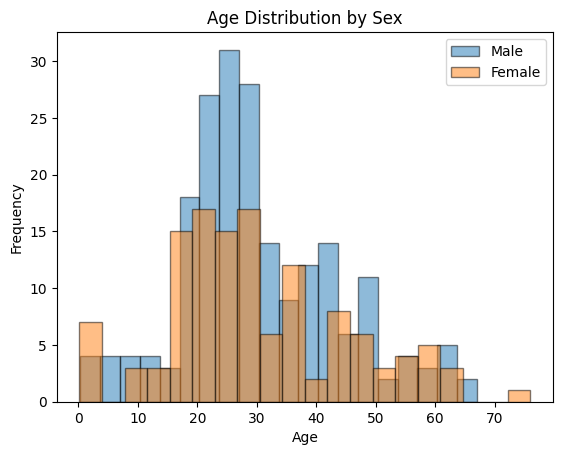

In [ ]:
male_ages = df[df['Sex'] == 'male']['Age'].dropna()
female_ages = df[df['Sex'] == 'female']['Age'].dropna()

plt.hist(male_ages, bins=20, alpha=0.5, label='Male', edgecolor='black')
plt.hist(female_ages, bins=20, alpha=0.5, label='Female', edgecolor='black')
plt.title("Age Distribution by Sex")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend()
plt.show()


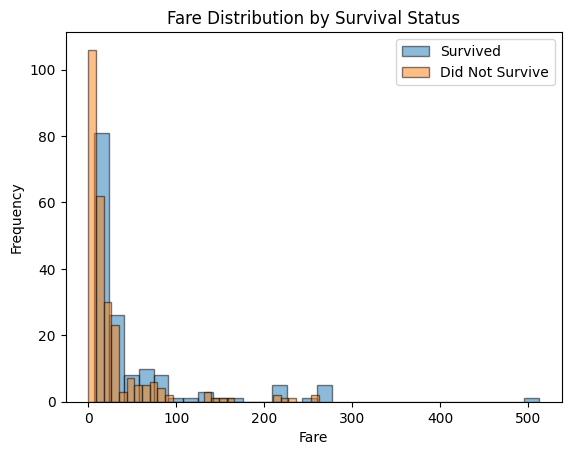

In [ ]:
survivor_fares = df[df['Survived'] == 1]['Fare'].dropna()
non_survivor_fares = df[df['Survived'] == 0]['Fare'].dropna()

plt.hist(survivor_fares, bins=30, alpha=0.5, label='Survived', edgecolor='black')
plt.hist(non_survivor_fares, bins=30, alpha=0.5, label='Did Not Survive', edgecolor='black')
plt.title("Fare Distribution by Survival Status")
plt.xlabel("Fare")
plt.ylabel("Frequency")
plt.legend()
plt.show()


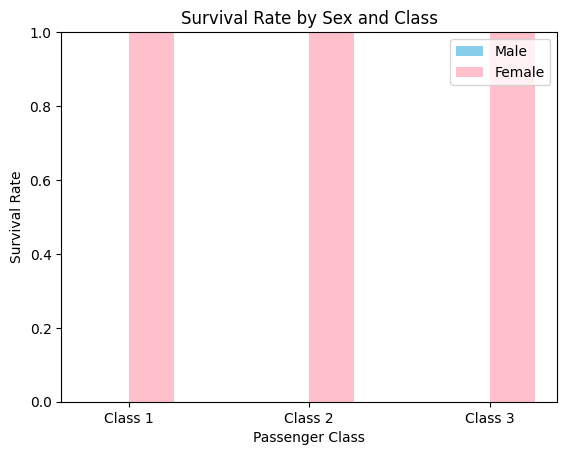

In [ ]:
grouped = df.groupby(['Sex', 'Pclass'])['Survived'].mean().unstack()

bar_width = 0.25
classes = grouped.columns
x = range(len(classes))

plt.bar([p - bar_width/2 for p in x], grouped.loc['male'], width=bar_width, label='Male', color='skyblue')
plt.bar([p + bar_width/2 for p in x], grouped.loc['female'], width=bar_width, label='Female', color='pink')

plt.xticks(x, [f"Class {c}" for c in classes])
plt.title("Survival Rate by Sex and Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.legend()
plt.show()


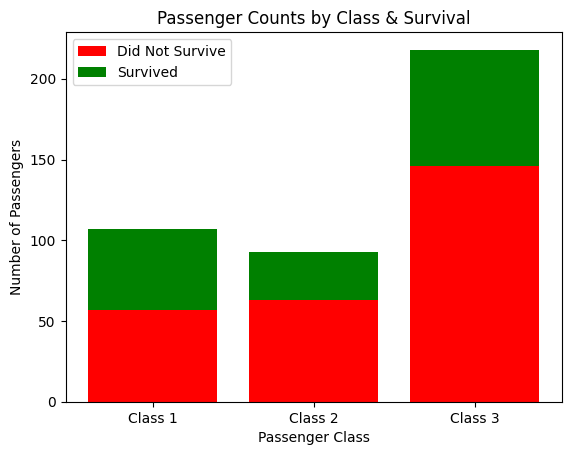

In [ ]:
counts = df.groupby(['Pclass', 'Survived'])['PassengerId'].count().unstack().fillna(0)

pclass = counts.index
survived_counts = counts[1]
not_survived_counts = counts[0]

plt.bar(pclass, not_survived_counts, label='Did Not Survive', color='red')
plt.bar(pclass, survived_counts, bottom=not_survived_counts, label='Survived', color='green')

plt.title("Passenger Counts by Class & Survival")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.xticks(pclass, [f"Class {c}" for c in pclass])
plt.legend()
plt.show()


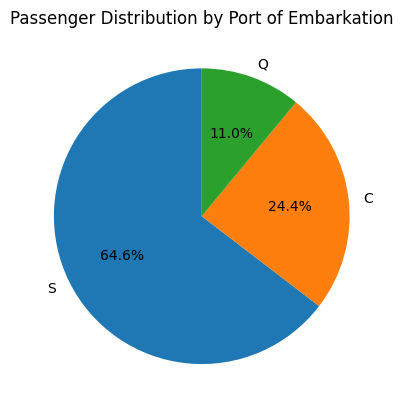

In [ ]:
embarked_counts = df['Embarked'].value_counts()

plt.pie(embarked_counts.values, labels=embarked_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Passenger Distribution by Port of Embarkation")
plt.show()


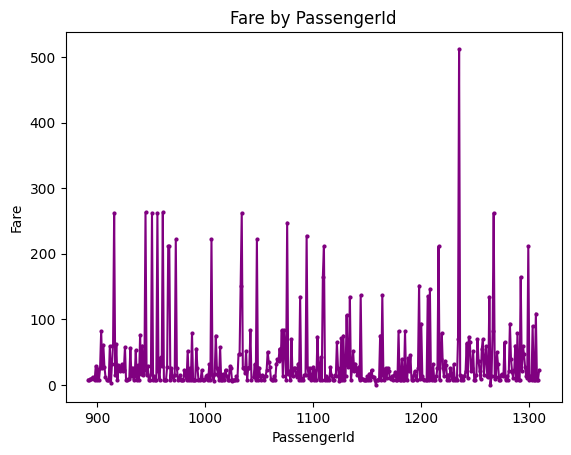

In [ ]:
plt.plot(df['PassengerId'], df['Fare'], color='purple', marker='o', markersize=2, linestyle='-')
plt.title("Fare by PassengerId")
plt.xlabel("PassengerId")
plt.ylabel("Fare")
plt.show()


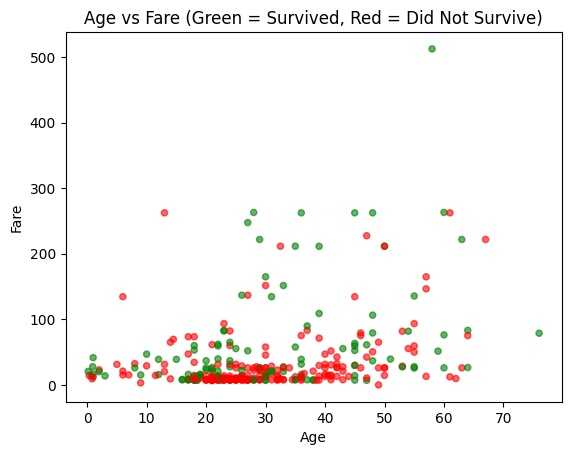

In [ ]:
colors = df['Survived'].map({0: 'red', 1: 'green'})
plt.scatter(df['Age'], df['Fare'], c=colors, alpha=0.6, s=20)
plt.title("Age vs Fare (Green = Survived, Red = Did Not Survive)")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()


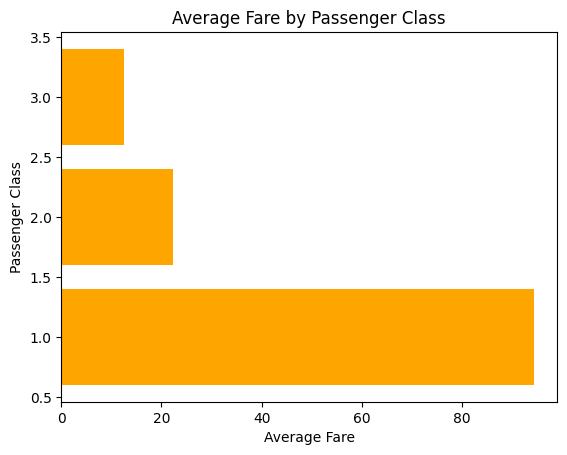

In [ ]:
avg_fare_by_class = df.groupby('Pclass')['Fare'].mean()

plt.barh(avg_fare_by_class.index, avg_fare_by_class.values, color='orange')
plt.title("Average Fare by Passenger Class")
plt.xlabel("Average Fare")
plt.ylabel("Passenger Class")
plt.show()


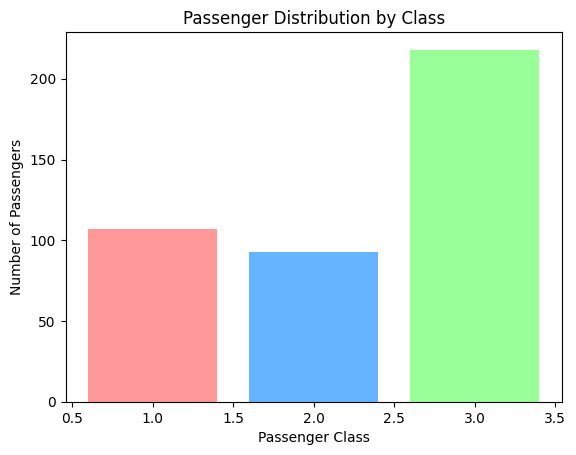

In [ ]:
# Count Pclass
pclass_counts = df['Pclass'].value_counts().sort_index()

# Plot
plt.bar(pclass_counts.index, pclass_counts.values, color=['#ff9999','#66b3ff','#99ff99'])
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.title("Passenger Distribution by Class")
plt.show()

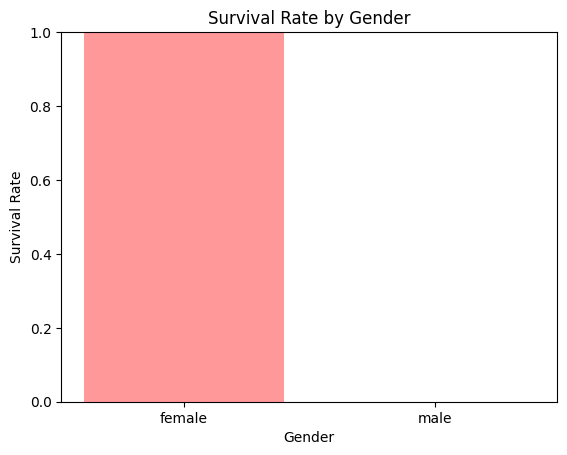

In [ ]:
# Calculate survival rate for each gender
survival_gender = df.groupby('Sex')['Survived'].mean()

plt.bar(survival_gender.index, survival_gender.values, color=['#ff9999', '#66b3ff'])
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Gender")
plt.ylim(0, 1)  # limit 0–1 for percentage
plt.show()


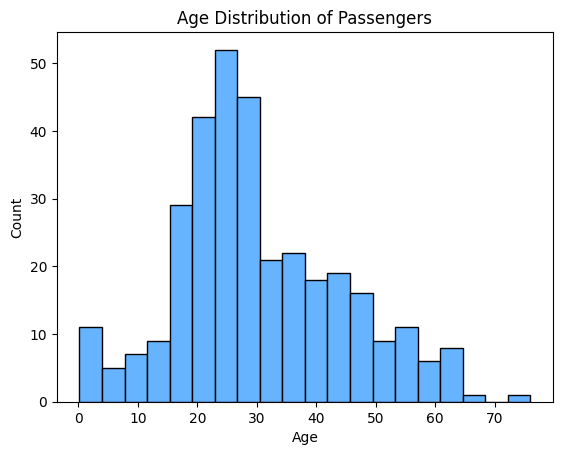

In [ ]:
plt.hist(df['Age'].dropna(), bins=20, color='#66b3ff', edgecolor='black')
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution of Passengers")
plt.show()


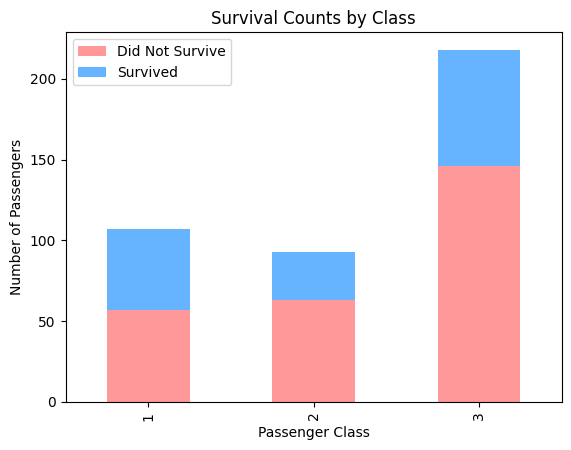

In [ ]:
# Prepare counts
survival_by_class = df.groupby(['Pclass', 'Survived'])['PassengerId'].count().unstack()

# Plot stacked bar
survival_by_class.plot(kind='bar', stacked=True, color=['#ff9999', '#66b3ff'])
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.title("Survival Counts by Class")
plt.legend(["Did Not Survive", "Survived"])
plt.show()


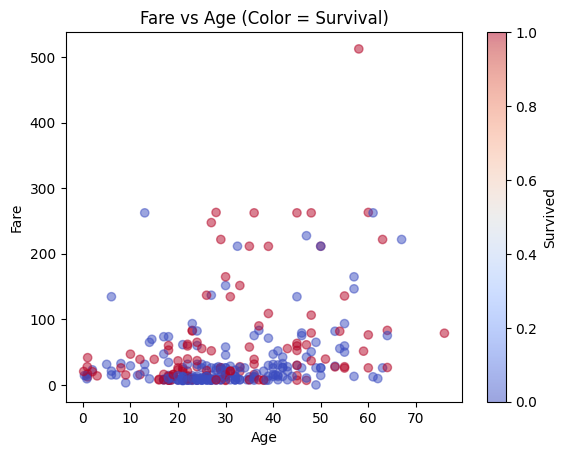

In [ ]:
plt.scatter(df['Age'], df['Fare'], alpha=0.5, c=df['Survived'], cmap='coolwarm')
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Fare vs Age (Color = Survival)")
plt.colorbar(label='Survived')
plt.show()


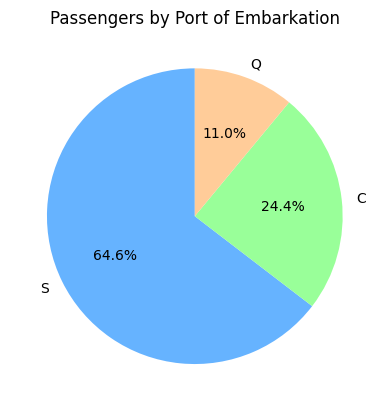

In [ ]:
embarked_counts = df['Embarked'].value_counts()

plt.pie(embarked_counts, labels=embarked_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=['#66b3ff', '#99ff99', '#ffcc99'])
plt.title("Passengers by Port of Embarkation")
plt.show()


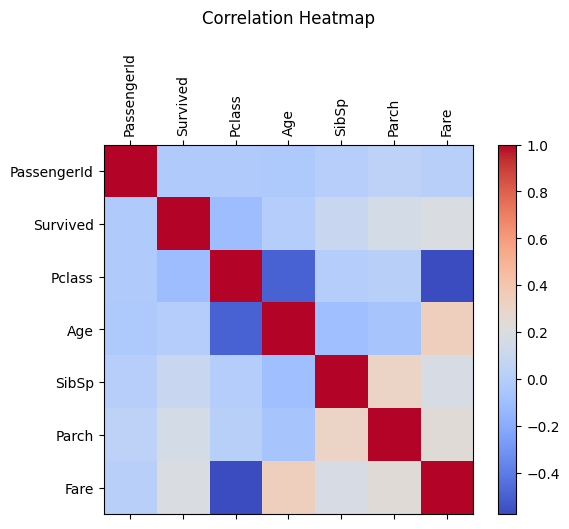

In [ ]:
import numpy as np

corr = df.corr(numeric_only=True)

fig, ax = plt.subplots()
cax = ax.matshow(corr, cmap='coolwarm')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
fig.colorbar(cax)
plt.title("Correlation Heatmap", pad=20)
plt.show()


In [ ]:
print("📊 Titanic EDA Summary")
print("- Most passengers were in 3rd class.")
print("- Females had a much higher survival rate than males.")
print("- The majority of passengers were between 20–40 years old.")
print("- Higher class passengers had better survival chances.")
print("- Port 'S' was the most common embarkation point.")
print("- Fare was positively correlated with survival.")


📊 Titanic EDA Summary
- Most passengers were in 3rd class.
- Females had a much higher survival rate than males.
- The majority of passengers were between 20–40 years old.
- Higher class passengers had better survival chances.
- Port 'S' was the most common embarkation point.
- Fare was positively correlated with survival.
